In [1]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# node2vec
from node2vec import Node2Vec

# deep stuff
import torch
from torch_geometric.utils import from_networkx

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.community_results import community_metrics, plot_communities
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.tune import tune

In [3]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [4]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [5]:
graphs = dict()

In [6]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [7]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [8]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

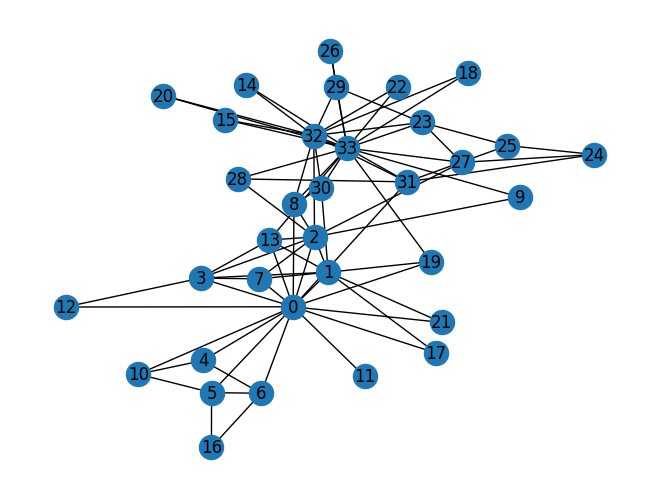

In [9]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

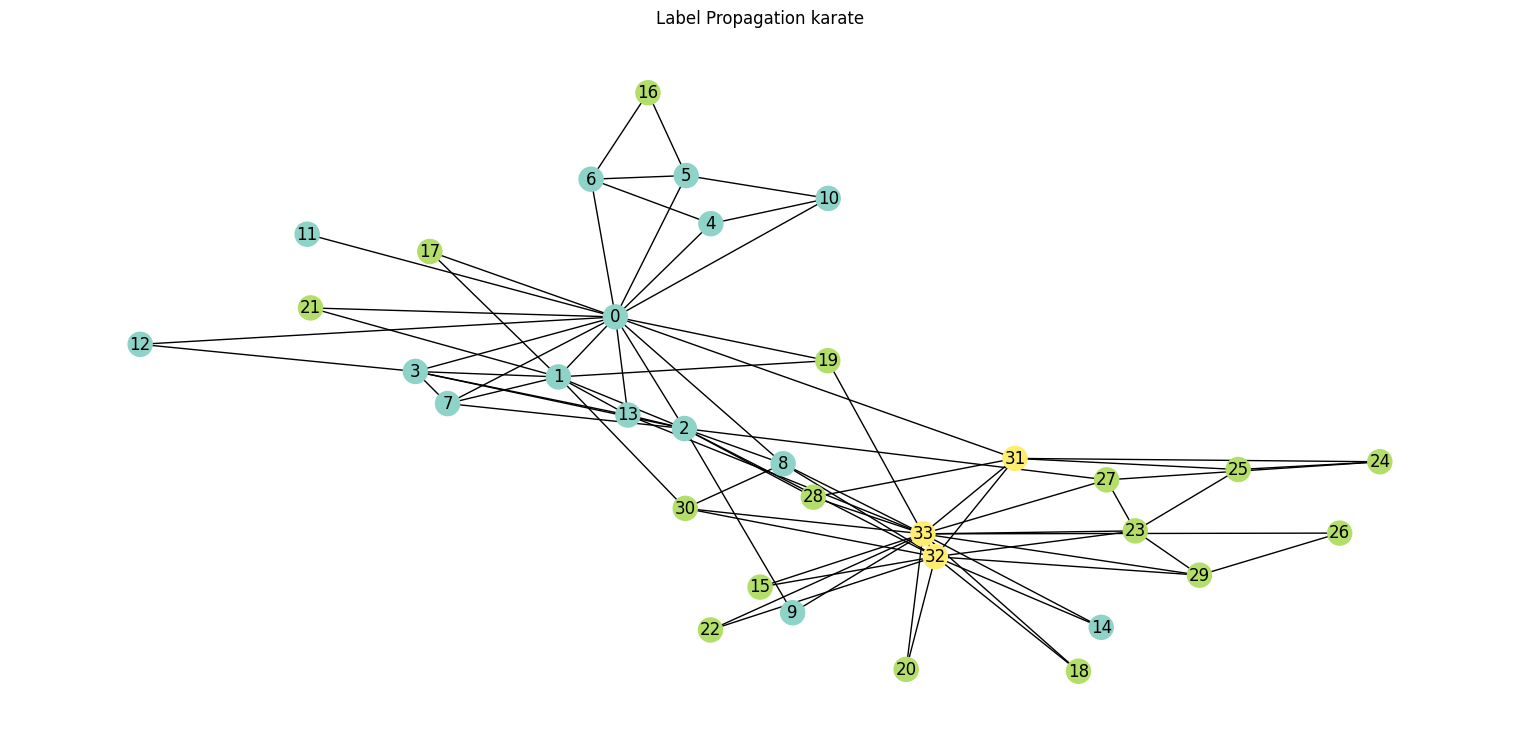

{'Number of Communities': 3,
 'Average Community Size': 11.333333333333334,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.30948632896684847,
 'Coverage': 0.7692307692307693,
 'Performance': 0.6684491978609626}

In [10]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}")

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

## Louvain

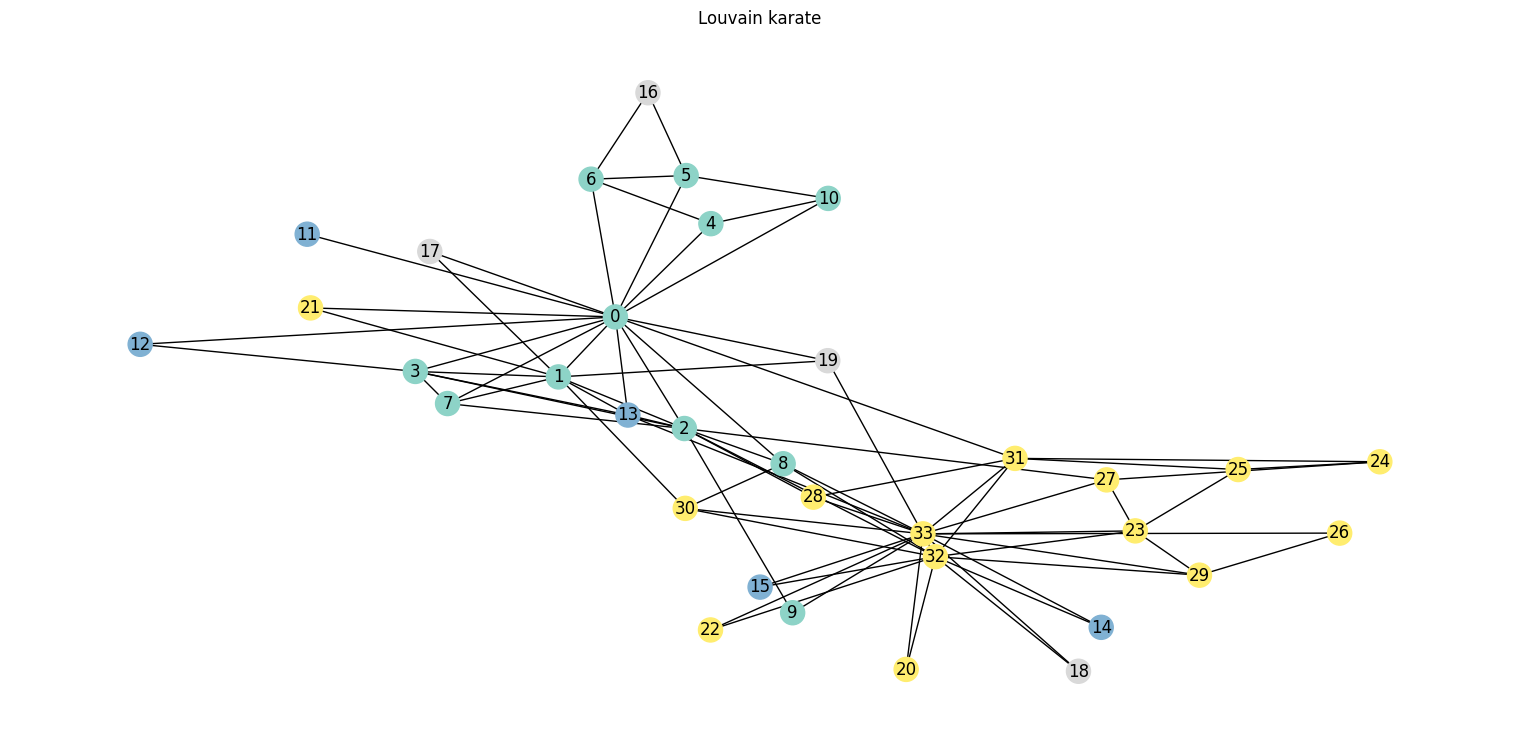

{'Number of Communities': 4,
 'Average Community Size': 8.5,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.4438541256723075,
 'Coverage': 0.7564102564102564,
 'Performance': 0.7825311942959001}

In [11]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}")

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

## Leiden

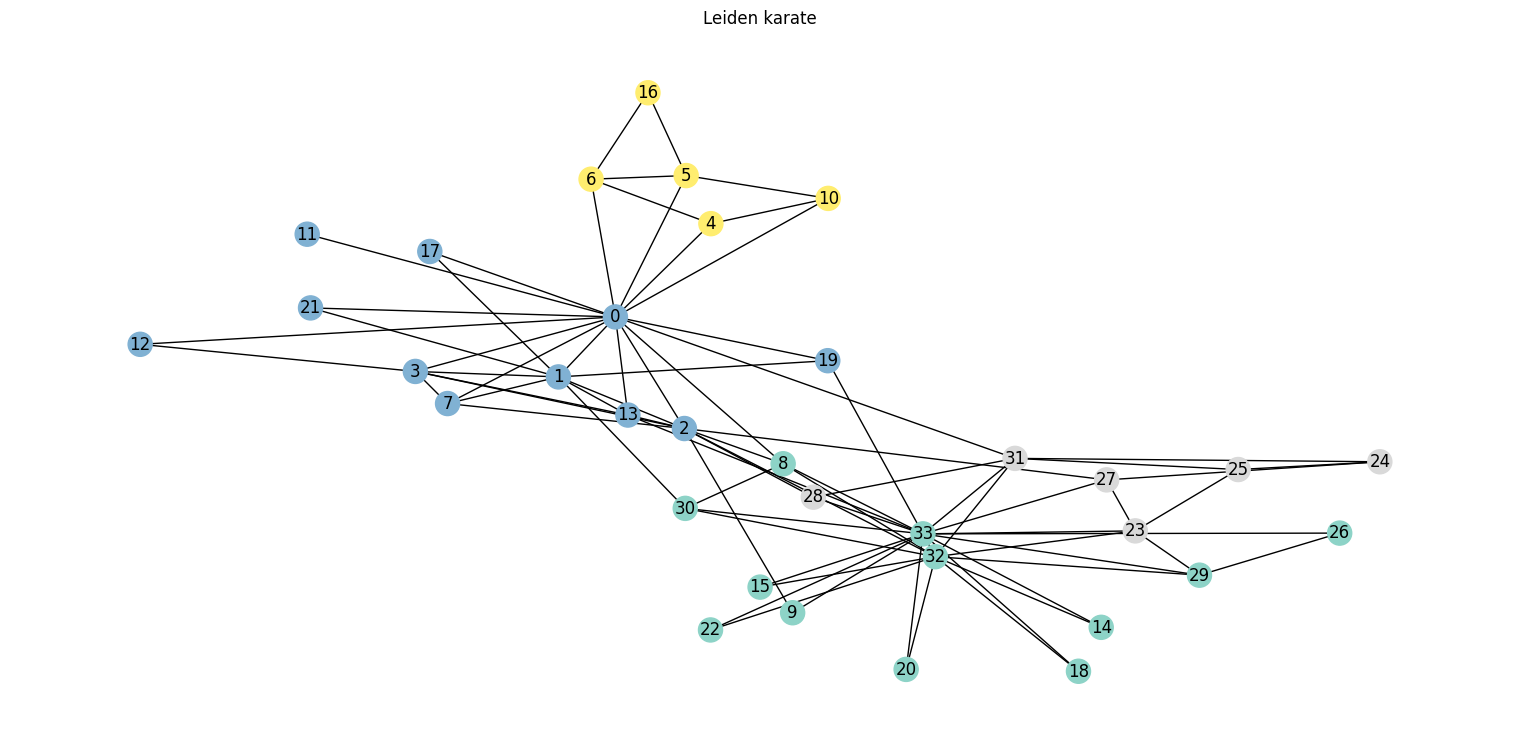

{'Number of Communities': 4,
 'Average Community Size': 8.5,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.44490358126721763,
 'Coverage': 0.7307692307692307,
 'Performance': 0.803921568627451}

In [12]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}")

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

# node2vec

In [13]:
node2vec = Node2Vec(g, dimensions=32, walk_length=20, num_walks=100, workers=4) 

# Embed nodes
# Any keywords acceptable by gensim.Word2Vec can be passed, 
# `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)  

Generating walks (CPU: 3): 100%|██████████| 25/25 [00:00<00:00, 1000.37it/s]


## Clustering using node2vec only

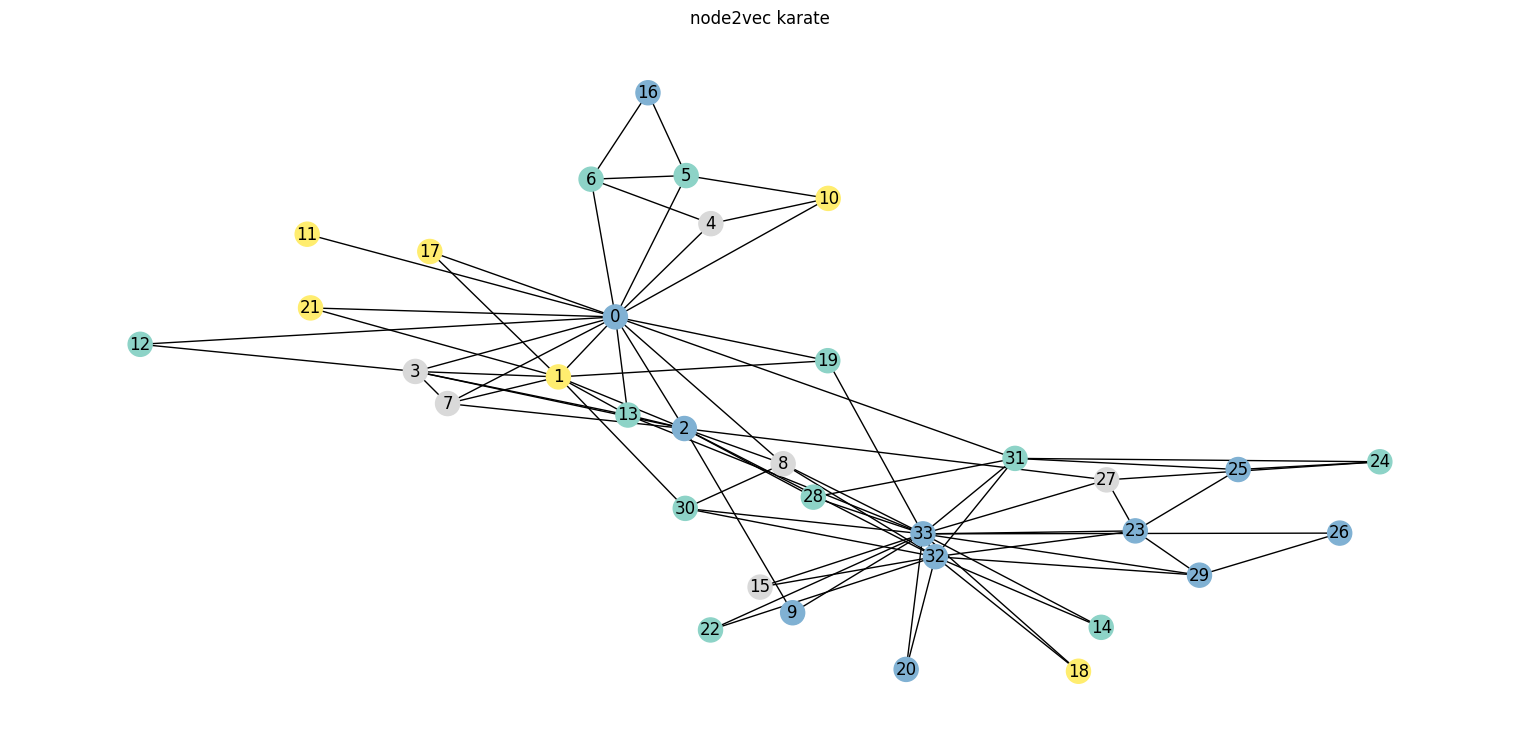

{'Number of Communities': 4,
 'Average Community Size': 8.5,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': -0.064241674631285,
 'Coverage': 0.2692307692307692,
 'Performance': 0.6862745098039216}

In [14]:
modularity, best_n, communities = optics(g, node2vec_model.wv.get_normed_vectors())

plot_communities(g, communities, title=f"node2vec {sel_graph}")
community_metrics(g, communities)

# Apply GAT Embedding

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [16]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [17]:
best_parameters_optuna = tune(data)
best_parameters_optuna

[I 2024-08-12 16:12:14,266] A new study created in memory with name: no-name-b2abda18-bf5a-40c1-bd4a-ee3b83077298
[I 2024-08-12 16:12:14,965] Trial 0 finished with value: 0.0682938856015779 and parameters: {'hidden_channels': 32, 'out_channels': 7, 'heads': 16, 'learning_rate': 0.005625310653111524, 'dropout': 0.12067272649652888, 'weight_decay': 1.195186684848196e-05}. Best is trial 0 with value: 0.0682938856015779.
[I 2024-08-12 16:12:15,773] Trial 1 finished with value: 0.4118178829717291 and parameters: {'hidden_channels': 43, 'out_channels': 25, 'heads': 14, 'learning_rate': 0.00010074598460731056, 'dropout': 0.1644417074146552, 'weight_decay': 0.0007577005523113254}. Best is trial 1 with value: 0.4118178829717291.
[I 2024-08-12 16:12:16,145] Trial 2 finished with value: 0.3599605522682445 and parameters: {'hidden_channels': 34, 'out_channels': 22, 'heads': 5, 'learning_rate': 0.0003896623812643079, 'dropout': 0.2716671391088169, 'weight_decay': 2.4694865720434946e-05}. Best is tr

In [18]:
best_parameters_optuna.best_value

0.41978961209730437

In [19]:
best_parameters = best_parameters_optuna.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 400
num_layers = 2

In [20]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(400):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')


Epoch 0, Loss: 1.4115147590637207
Epoch 10, Loss: 1.4070873260498047
Epoch 20, Loss: 1.3808081150054932
Epoch 30, Loss: 1.352902889251709
Epoch 40, Loss: 1.3253633975982666
Epoch 50, Loss: 1.3628610372543335
Epoch 60, Loss: 1.2710174322128296
Epoch 70, Loss: 1.3215975761413574
Epoch 80, Loss: 1.15684175491333
Epoch 90, Loss: 1.1079071760177612
Epoch 100, Loss: 1.1376919746398926
Epoch 110, Loss: 1.0298103094100952
Epoch 120, Loss: 1.0874210596084595
Epoch 130, Loss: 1.278771162033081
Epoch 140, Loss: 1.1644566059112549
Epoch 150, Loss: 0.931652307510376
Epoch 160, Loss: 0.705238401889801
Epoch 170, Loss: 1.0447771549224854
Epoch 180, Loss: 0.9694218635559082
Epoch 190, Loss: 0.674527108669281
Epoch 200, Loss: 0.834396481513977
Epoch 210, Loss: 0.8834428787231445
Epoch 220, Loss: 0.8657741546630859
Epoch 230, Loss: 0.7493534088134766
Epoch 240, Loss: 0.7072266340255737
Epoch 250, Loss: 0.9551960229873657
Epoch 260, Loss: 0.6007758378982544
Epoch 270, Loss: 0.6354069709777832
Epoch 280, 

In [21]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index)

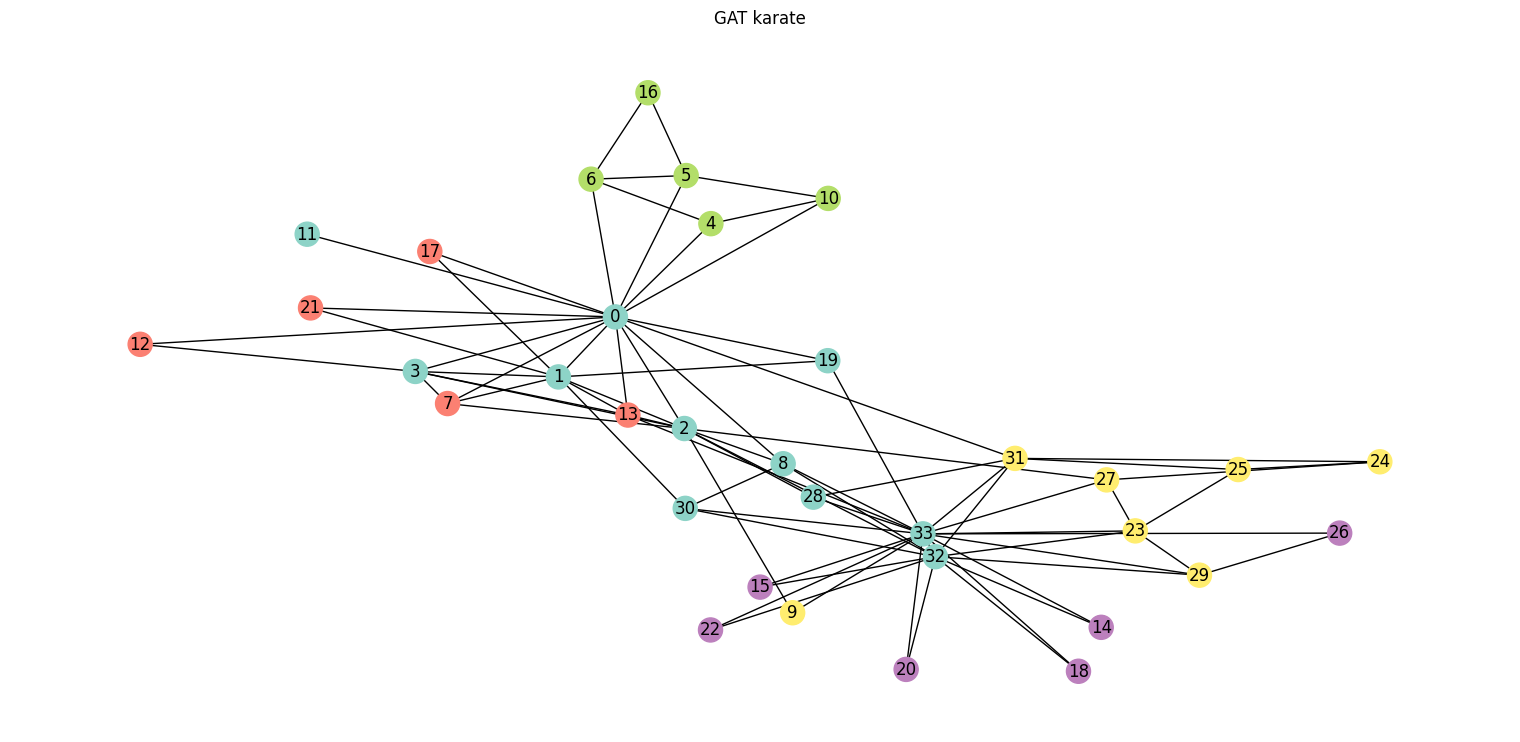

{'Number of Communities': 5,
 'Average Community Size': 6.8,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.13336519180675033,
 'Coverage': 0.44871794871794873,
 'Performance': 0.7878787878787878}

In [22]:
modularity, best_n, communities = optics(g, node_embeddings.detach().cpu().numpy())

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, communities)

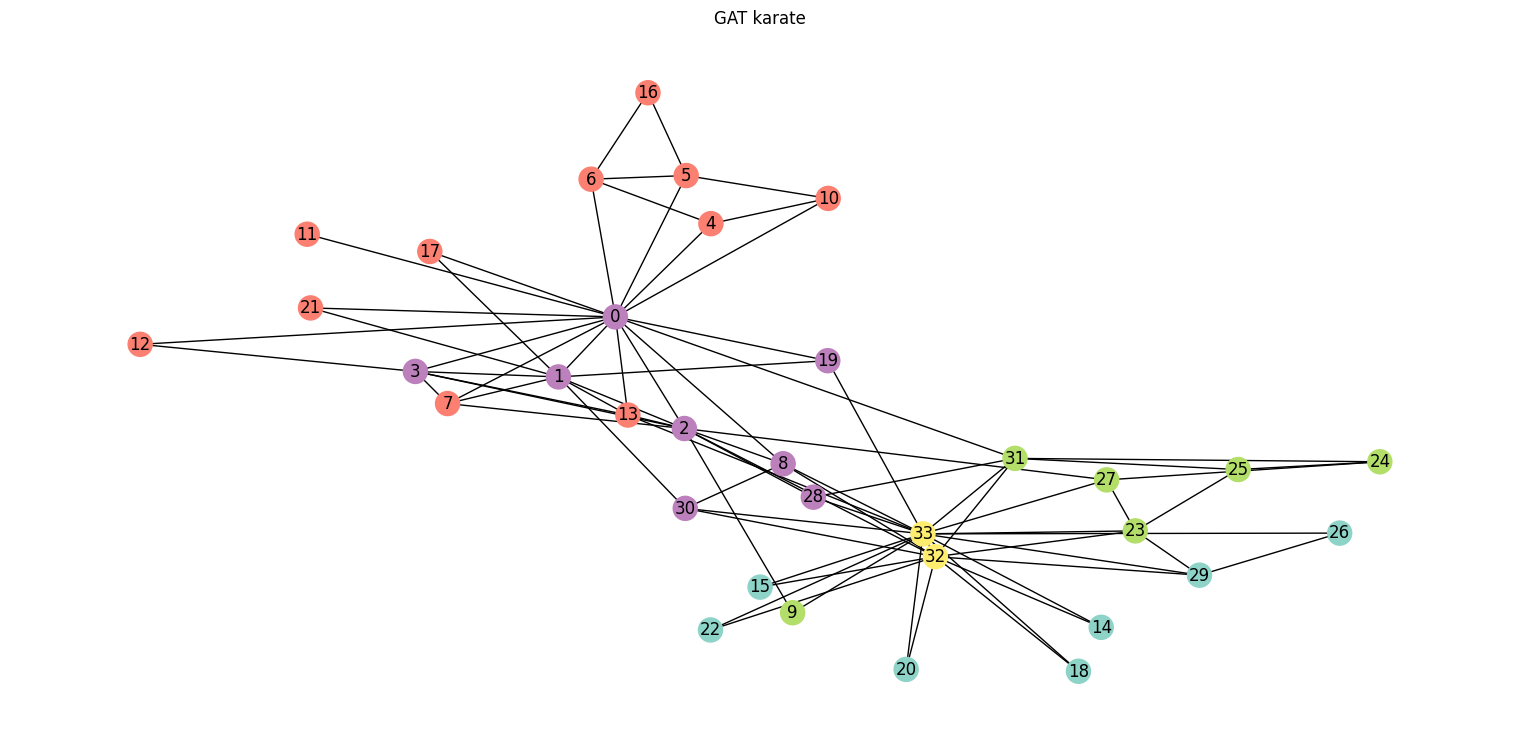

{'Number of Communities': 5,
 'Average Community Size': 6.8,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.16808155769194733,
 'Coverage': 0.34615384615384615,
 'Performance': 0.7433155080213903}

In [23]:
modularity, best_n, communities = kmeans(g, node_embeddings.detach().cpu().numpy())

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, communities)

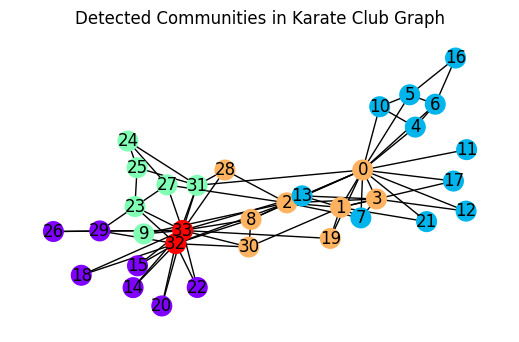

In [26]:
# Plotting the communities
plt.figure(figsize=(5, 3))
nx.draw(g, node_color=list(communities.values()), with_labels=True, cmap=plt.cm.rainbow, node_size=200)
plt.title("Detected Communities in Karate Club Graph")
plt.show()